# Predictive modeling of customer bookings

**In this Jupyternotebook, we will focus on Data Pre-processing & Modeling.**

---

### Data Pre-processing

First, we must explore the data in order to better understand what we have and the statistical properties of the dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../Data/customer_booking_v1.csv", encoding="ISO-8859-1", index_col=0)
df.head()

,num_passengers,purchase_lead,length_of_stay,flight_hour,add_ons_count,flight_duration,sales_channel,trip_type,flight_day,route,...,wants_in_flight_meals,departure_city,arrival_city,is_weekend,booking_urgency,long_haul,is_AM,departure_country,arrival_country,booking_complete
0,2,262,19,7,1,5.52,Internet,RoundTrip,6,AKLDEL,...,0,AKL,DEL,1,0,0,1,New Zealand,India,0
1,1,112,20,3,0,5.52,Internet,RoundTrip,6,AKLDEL,...,0,AKL,DEL,1,0,0,1,New Zealand,India,0
2,2,243,22,17,2,5.52,Internet,RoundTrip,3,AKLDEL,...,0,AKL,DEL,0,0,0,0,New Zealand,India,0
3,1,96,31,4,1,5.52,Internet,RoundTrip,6,AKLDEL,...,1,AKL,DEL,1,0,0,1,New Zealand,India,0
4,2,68,22,15,2,5.52,Internet,RoundTrip,3,AKLDEL,...,1,AKL,DEL,0,0,0,0,New Zealand,India,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   purchase_lead          50000 non-null  int64  
 2   length_of_stay         50000 non-null  int64  
 3   flight_hour            50000 non-null  int64  
 4   add_ons_count          50000 non-null  int64  
 5   flight_duration        50000 non-null  float64
 6   sales_channel          50000 non-null  object 
 7   trip_type              50000 non-null  object 
 8   flight_day             50000 non-null  int64  
 9   route                  50000 non-null  object 
 10  booking_origin         50000 non-null  object 
 11  wants_extra_baggage    50000 non-null  int64  
 12  wants_preferred_seat   50000 non-null  int64  
 13  wants_in_flight_meals  50000 non-null  int64  
 14  departure_city         50000 non-null  object 
 15  ar

In [4]:
# Convert the 'sales_channel'to a dummy encoded Data Frame
df_one_hot = pd.get_dummies(df, columns=['sales_channel'], drop_first=True)
print(df_one_hot.columns)

Index(['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour',
       'add_ons_count', 'flight_duration', 'trip_type', 'flight_day', 'route',
       'booking_origin', 'wants_extra_baggage', 'wants_preferred_seat',
       'wants_in_flight_meals', 'departure_city', 'arrival_city', 'is_weekend',
       'booking_urgency', 'long_haul', 'is_AM', 'departure_country',
       'arrival_country', 'booking_complete', 'sales_channel_Mobile'],
      dtype='object')


In [5]:
# Convert the 'trip_type'to a one hot encoded Data Frame
df_one_hot = pd.get_dummies(df_one_hot, columns=['trip_type'], drop_first=False)
print(df_one_hot.columns)


Index(['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour',
       'add_ons_count', 'flight_duration', 'flight_day', 'route',
       'booking_origin', 'wants_extra_baggage', 'wants_preferred_seat',
       'wants_in_flight_meals', 'departure_city', 'arrival_city', 'is_weekend',
       'booking_urgency', 'long_haul', 'is_AM', 'departure_country',
       'arrival_country', 'booking_complete', 'sales_channel_Mobile',
       'trip_type_CircleTrip', 'trip_type_OneWay', 'trip_type_RoundTrip'],
      dtype='object')


In [6]:
# Use binary encoding to convert the 'booking_origin', 'route', 'departure_city', 'arrival_city', 'departure_country' and 'arrival_country' columns to numerical values
from category_encoders import BinaryEncoder
encoder = BinaryEncoder(cols=['booking_origin', 'route', 'departure_city', 'arrival_city', 'departure_country', 'arrival_country'])
df_one_hot_binary = encoder.fit_transform(df_one_hot)
print(df_one_hot_binary.columns)

Index(['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour',
       'add_ons_count', 'flight_duration', 'flight_day', 'route_0', 'route_1',
       'route_2', 'route_3', 'route_4', 'route_5', 'route_6', 'route_7',
       'route_8', 'route_9', 'booking_origin_0', 'booking_origin_1',
       'booking_origin_2', 'booking_origin_3', 'booking_origin_4',
       'booking_origin_5', 'booking_origin_6', 'wants_extra_baggage',
       'wants_preferred_seat', 'wants_in_flight_meals', 'departure_city_0',
       'departure_city_1', 'departure_city_2', 'departure_city_3',
       'departure_city_4', 'departure_city_5', 'departure_city_6',
       'arrival_city_0', 'arrival_city_1', 'arrival_city_2', 'arrival_city_3',
       'arrival_city_4', 'arrival_city_5', 'arrival_city_6', 'is_weekend',
       'booking_urgency', 'long_haul', 'is_AM', 'departure_country_0',
       'departure_country_1', 'departure_country_2', 'departure_country_3',
       'departure_country_4', 'arrival_country_0', 'arri

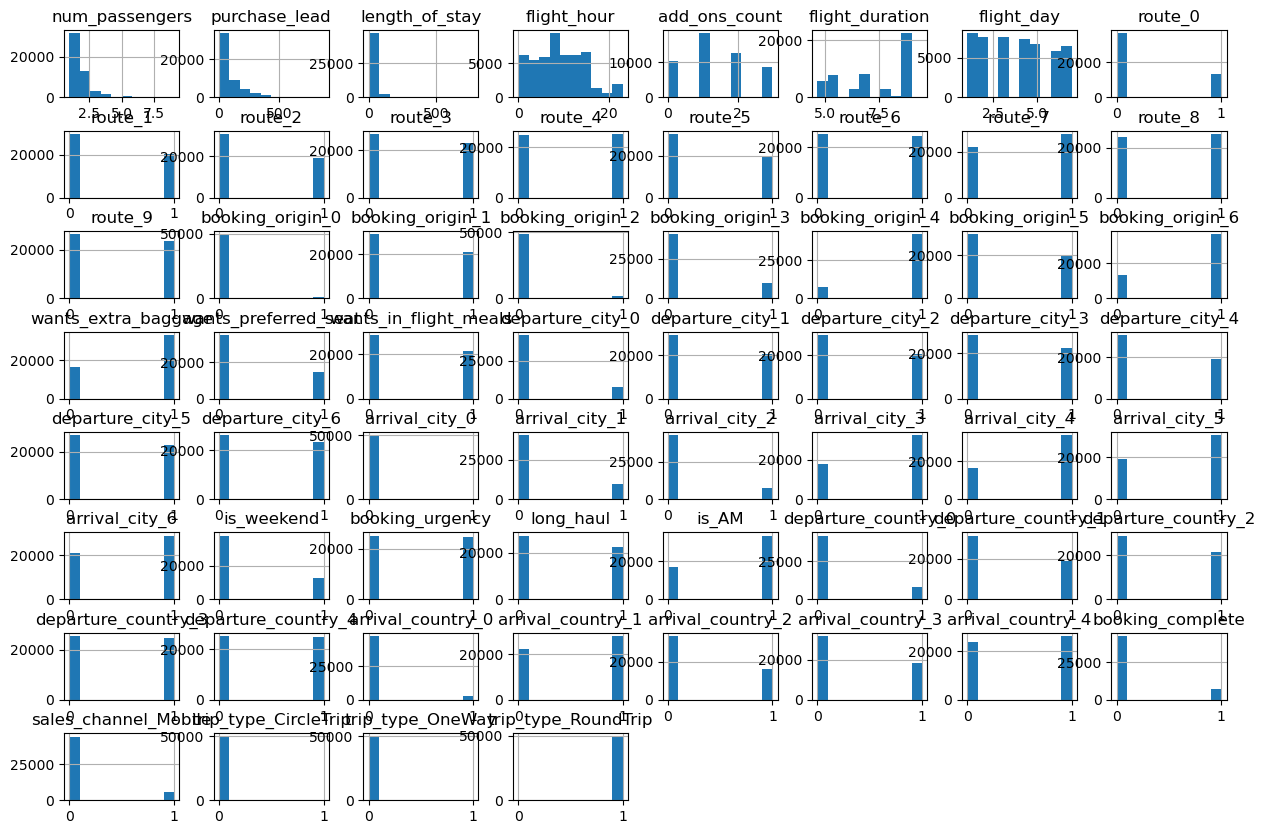

In [7]:
df_one_hot_binary.hist(figsize=(15,10))
plt.subplots_adjust(hspace=0.5)

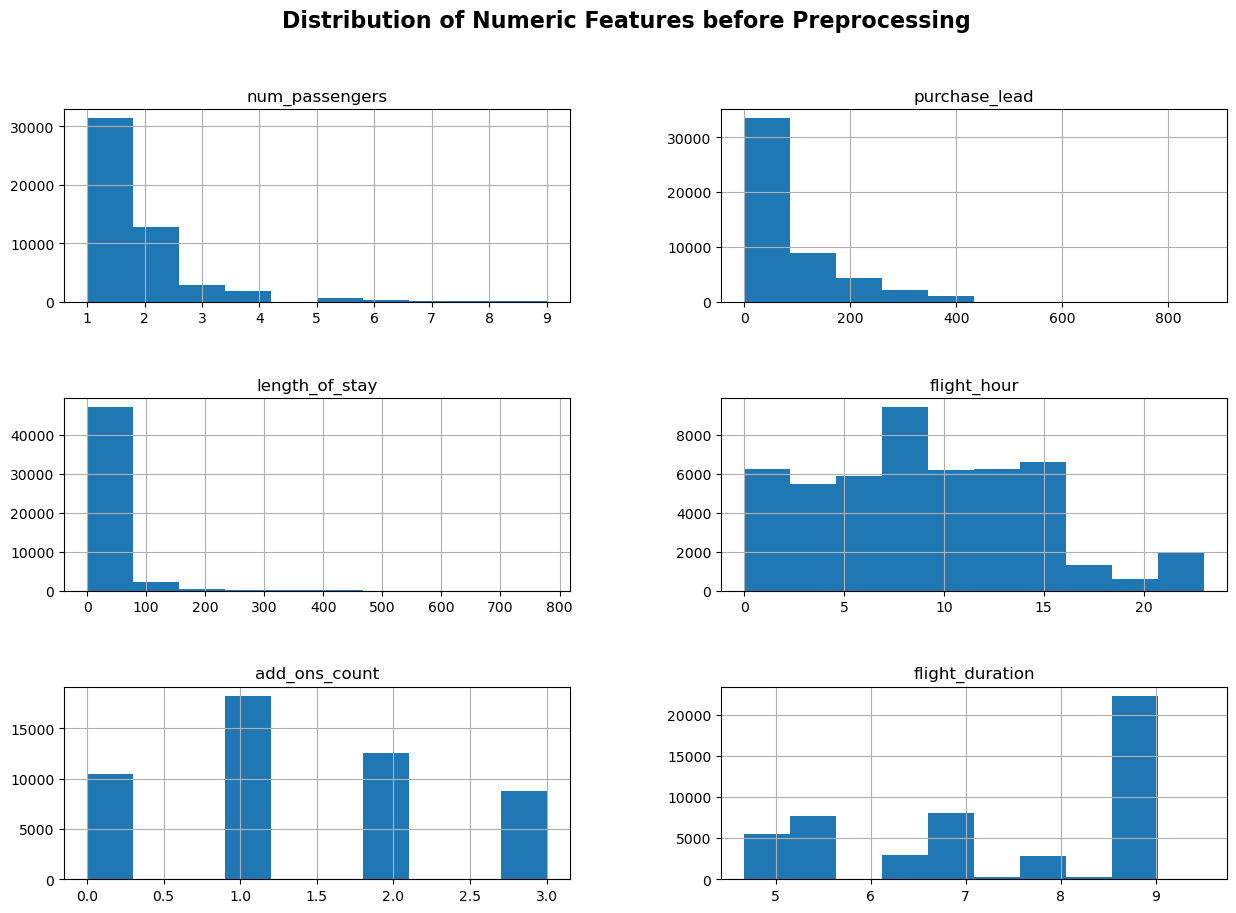

In [8]:
df_one_hot_binary.loc[:, "num_passengers":"flight_duration"].hist(figsize=(15,10))
plt.subplots_adjust(hspace=0.5)
plt.suptitle("Distribution of Numeric Features before Preprocessing", fontsize=16, fontweight="bold")
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler

In [10]:
# Subsetting our data into our dependent and independent variables.
y = df_one_hot_binary[['booking_complete']]
X = df_one_hot_binary.drop('booking_complete', axis=1)

# Split the data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=22, stratify=y)
X_train.head()

,num_passengers,purchase_lead,length_of_stay,flight_hour,add_ons_count,flight_duration,flight_day,route_0,route_1,route_2,...,departure_country_4,arrival_country_0,arrival_country_1,arrival_country_2,arrival_country_3,arrival_country_4,sales_channel_Mobile,trip_type_CircleTrip,trip_type_OneWay,trip_type_RoundTrip
22526,2,55,22,11,3,5.62,5,1,0,0,...,0,0,1,0,0,1,0,0,0,1
29463,1,203,4,5,2,7.57,4,0,0,0,...,0,0,0,0,1,1,0,0,0,1
36330,7,49,5,8,3,8.67,2,0,0,1,...,0,0,0,1,1,0,0,0,0,1
1028,1,16,84,14,0,8.83,7,0,0,0,...,1,0,0,1,1,0,0,0,0,1
4580,1,182,17,2,1,6.62,1,0,0,1,...,0,0,0,1,0,0,0,0,0,1


In [11]:
# Instantiate a log transformer
pow_trans = PowerTransformer()

# Instantiate a scaler
scaler = StandardScaler()

# Build steps for the preprocessing pipeline
steps = [("log_transform", pow_trans),
        ('standardization', scaler)]

# Set up pipeline
pipeline = Pipeline(steps)

# Apply fit_transform to numerical variables of X_train
X_train_num = pipeline.fit_transform(X_train.loc[:,'num_passengers':'flight_duration'])

# Apply transform to numerical variables of X_test
X_test_num = pipeline.transform(X_test.loc[:,'num_passengers':'flight_duration'])

In [12]:
# Recreate a DataFrame of the numeric features for X_train with the original column names and the same index as X_train
X_train_num = pd.DataFrame(X_train_num, 
                          columns=X_train.columns[:6])
X_train_num.index = X_train.index

# Recreate a DataFrame of all the features (numerical + categorical) for X_train
X_train = pd.concat([X_train_num, X_train.loc[:,'flight_day':'trip_type_RoundTrip']], axis=1)
X_train.describe()


,num_passengers,purchase_lead,length_of_stay,flight_hour,add_ons_count,flight_duration,flight_day,route_0,route_1,route_2,...,departure_country_4,arrival_country_0,arrival_country_1,arrival_country_2,arrival_country_3,arrival_country_4,sales_channel_Mobile,trip_type_CircleTrip,trip_type_OneWay,trip_type_RoundTrip
count,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,40000.000000,40000.00000,40000.000000,40000.00000,...,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,-1.154632e-17,-1.572076e-17,2.273737e-17,-1.652012e-17,3.410605e-17,-4.014566e-17,3.815400,0.27055,0.403100,0.38700,...,0.498325,0.059150,0.555475,0.327325,0.364650,0.526725,0.113750,0.002300,0.007625,0.990075
std,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.993482,0.44425,0.490527,0.48707,...,0.500003,0.235908,0.496919,0.469243,0.481338,0.499292,0.317511,0.047904,0.086989,0.099130
min,-7.613986e-01,-2.453460e+00,-3.685616e+00,-2.089031e+00,-1.510817e+00,-1.591343e+00,1.000000,0.00000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-7.613986e-01,-7.026445e-01,-8.282823e-01,-6.766108e-01,-2.991191e-01,-1.122553e+00,2.000000,0.00000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,-7.613986e-01,-6.936491e-03,3.847092e-01,1.027939e-01,-2.991191e-01,9.970523e-02,4.000000,0.00000,0.000000,0.00000,...,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,1.116605e+00,7.091353e-01,8.157852e-01,7.669686e-01,6.569996e-01,1.079818e+00,5.000000,1.00000,1.000000,1.00000,...,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,1.836573e+00,3.065707e+00,2.719832e+00,2.162449e+00,1.477603e+00,1.662992e+00,7.000000,1.00000,1.000000,1.00000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


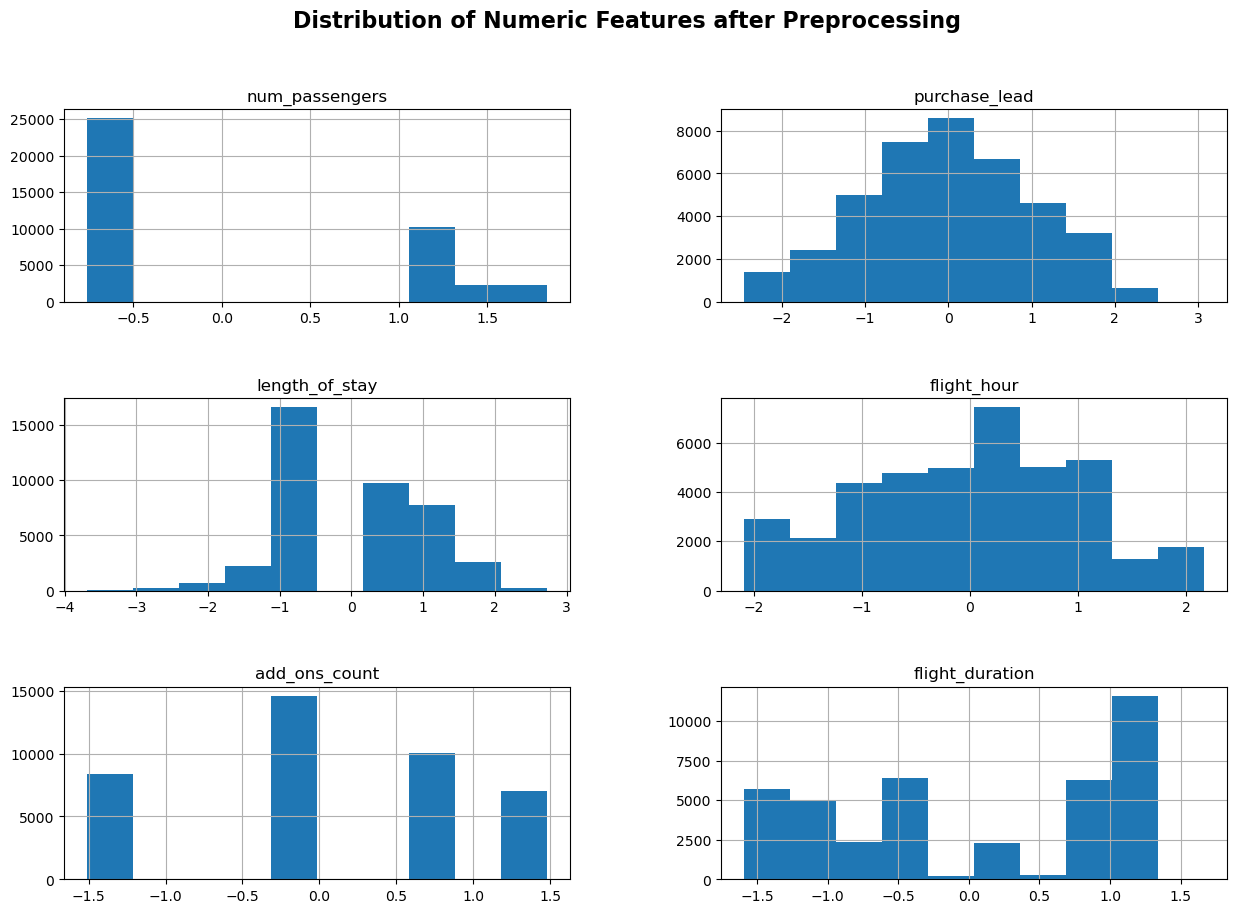

In [13]:
# Look into distributions of feature values after preprocessing
X_train.loc[:, "num_passengers":"flight_duration"].hist(figsize=(15,10))
plt.subplots_adjust(hspace=0.5)
plt.suptitle("Distribution of Numeric Features after Preprocessing", fontsize=16, fontweight="bold")
plt.show()

In [14]:
# Likewise, recreate a DataFrame of all the features (numerical + categorical) for X_test
X_test_num = pd.DataFrame(X_test_num, 
                          columns=X_test.columns[:6])
X_test_num.index = X_test.index

# Recreate a DataFrame of all the features (numerical + categorical) for X_test
X_test = pd.concat([X_test_num, X_test.loc[:,'flight_day':'trip_type_RoundTrip']], axis=1)
X_test.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,add_ons_count,flight_duration,flight_day,route_0,route_1,route_2,...,departure_country_4,arrival_country_0,arrival_country_1,arrival_country_2,arrival_country_3,arrival_country_4,sales_channel_Mobile,trip_type_CircleTrip,trip_type_OneWay,trip_type_RoundTrip
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000,...,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.003961,-0.009040,-0.002244,0.006091,-0.003451,-0.005968,3.810500,0.271400,0.4086,0.382100,...,0.490100,0.05670,0.558500,0.328300,0.367200,0.52520,0.106800,0.002400,0.008200,0.989400
std,1.000600,1.004561,1.003696,0.996031,1.003179,0.997953,1.990122,0.444704,0.4916,0.485925,...,0.499927,0.23128,0.496591,0.469618,0.482066,0.49939,0.308874,0.048933,0.090186,0.102414
min,-0.761399,-2.453460,-3.685616,-2.089031,-1.510817,-1.591343,1.000000,0.000000,0.0000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,-0.761399,-0.702644,-0.828282,-0.676611,-0.299119,-1.122553,2.000000,0.000000,0.0000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000
50%,-0.761399,-0.039650,0.384709,0.102794,-0.299119,0.099705,4.000000,0.000000,0.0000,0.000000,...,0.000000,0.00000,1.000000,0.000000,0.000000,1.00000,0.000000,0.000000,0.000000,1.000000
75%,1.116605,0.709135,0.815785,0.766969,0.657000,1.079818,5.000000,1.000000,1.0000,1.000000,...,1.000000,0.00000,1.000000,1.000000,1.000000,1.00000,0.000000,0.000000,0.000000,1.000000
max,1.836573,2.641433,2.722235,2.162449,1.477603,1.662992,7.000000,1.000000,1.0000,1.000000,...,1.000000,1.00000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000


In [16]:
# Save the data to a new csv file for futher analysis
X_train.to_csv('../Data/X_train.csv') 
X_test.to_csv('../Data/X_test.csv')
y_train.to_csv('../Data/y_train.csv') 
y_test.to_csv('../Data/y_test.csv')

### Data Modeling

In [17]:
import time
from sklearn.model_selection import KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, log_loss, recall_score, precision_score,confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

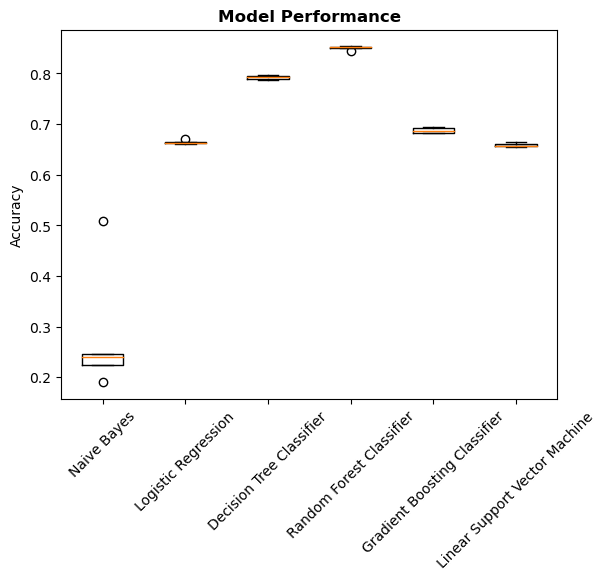

In [18]:
# Compute sample weights for handling class imbalance

from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train.values.ravel()
)

# Create models dictionary
models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=22), 
    "Decision Tree Classifier": DecisionTreeClassifier(random_state=22),
    "Random Forest Classifier": RandomForestClassifier(random_state=22),
    "Gradient Boosting Classifier": GradientBoostingClassifier(random_state=22),
    "Linear Support Vector Machine": LinearSVC(max_iter=10000, random_state=22)
}
results = []

# Loop through the models' values
for model in models.values():
  
  # Instantiate a KFold object to perform 5 splits, setting shuffle to True and random_state to 22.
  kf = KFold(n_splits=5, random_state=22, shuffle=True)
  
  # Perform cross-validation
  cv_results = cross_val_score(model, X_train, y_train.values.ravel(), cv=kf, fit_params={"sample_weight": sample_weights})
  results.append(cv_results)
plt.boxplot(results, labels=models.keys())
plt.xticks(rotation=45)
plt.title("Model Performance", fontweight="bold")
plt.ylabel("Accuracy")
plt.show()

In [19]:
# Decision Tree Classifier
# Create the parameter space
params = {'criterion': ['entropy', 'gini'],
          'max_depth': np.arange(1,50)}

# Instantiate a KFold object to perform 5 splits, setting shuffle to True and random_state to 22.
kf = KFold(n_splits=5, random_state=22, shuffle=True)

# Instantiate the GridSearchCV object
dtc_cv = GridSearchCV(DecisionTreeClassifier(random_state=22), params, cv=kf)

start_time = time.time()

# Fit the data to the model
dtc_cv.fit(X_train, y_train.values.ravel(), sample_weight=sample_weights)

elapsed_time = time.time() - start_time
print("GridSearchCV Run Time: %.3f" % (elapsed_time))

# Print the tuned parameters and score
print("Tuned Decision Tree Parameters: {}".format(dtc_cv.best_params_))
print("Tuned Decision Tree Best Accuracy Score: %.3f" % (dtc_cv.best_score_))

GridSearchCV Run Time: 79.494
Tuned Decision Tree Parameters: {'criterion': 'entropy', 'max_depth': 31}
Tuned Decision Tree Best Accuracy Score: 0.793


In [20]:
# Random Forest Classifier
# Create the parameter space
params = {'criterion': ['entropy', 'gini'],
          'n_estimators': np.linspace(start = 100, stop = 2000, num = 20, dtype=int),
          'max_depth': np.linspace(5, 30, 6, dtype=int)}

# Instantiate a KFold object to perform 5 splits, setting shuffle to True and random_state to 22.
kf = KFold(n_splits=5, random_state=22, shuffle=True)

# Instantiate the RandomizedSearchCV object
rfc_cv = RandomizedSearchCV(RandomForestClassifier(random_state=22), params, cv=kf, random_state=22, verbose=1)

start_time = time.time()

# Fit the data to the model
rfc_cv.fit(X_train, y_train.values.ravel())

elapsed_time = time.time() - start_time
print("RandomizedSearchCV Run Time: %.3f" % (elapsed_time))

# Print the tuned parameters and score
print("Tuned Random Forest Parameters: {}".format(rfc_cv.best_params_))
print("Tuned Random Forest Best Accuracy Score: %.3f" % (rfc_cv.best_score_))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
RandomizedSearchCV Run Time: 906.217
Tuned Random Forest Parameters: {'n_estimators': 1000, 'max_depth': 15, 'criterion': 'entropy'}
Tuned Random Forest Best Accuracy Score: 0.852


In [21]:
# Gradient Boosting Classifier
# Create the parameter space
params = {'n_estimators': np.linspace(start = 100, stop = 1000, num = 10, dtype=int),
          'learning_rate': [0.01, 0.05, 0.1],
          'max_depth': [3, 5, 6]}

# Instantiate a KFold object to perform 5 splits, setting shuffle to True and random_state to 22.
kf = KFold(n_splits=5, random_state=22, shuffle=True)

# Instantiate the RandomizedSearchCV object
gbc_cv = RandomizedSearchCV(GradientBoostingClassifier(random_state=22), params, cv=kf, random_state=22)

start_time = time.time()

# Fit the data to the model
gbc_cv.fit(X_train, y_train.values.ravel(), sample_weight=sample_weights)

elapsed_time = time.time() - start_time
print("RandomizedSearchCV Run Time: %.3f" % (elapsed_time))

# Print the tuned parameters and score
print("Tuned Gradient Boosting Parameters: {}".format(gbc_cv.best_params_))
print("Tuned Gradient Boosting Best Accuracy Score: %.3f" % (gbc_cv.best_score_))

RandomizedSearchCV Run Time: 3236.001
Tuned Gradient Boosting Parameters: {'n_estimators': 1000, 'max_depth': 6, 'learning_rate': 0.1}
Tuned Gradient Boosting Best Accuracy Score: 0.804


In [22]:
# Apply the turned hyperparameters to the models

# Instantiate a KFold object to perform 5 splits, setting shuffle to True and random_state to 22.
kf = KFold(n_splits=5, random_state=22, shuffle=True)

# Instantiate the Decision Tree Classifier model
dtc = DecisionTreeClassifier(criterion='entropy',
                              max_depth=31,
                              random_state=22)

# Instantiate the Random Forest Classifier model
rfc = RandomForestClassifier(criterion = 'entropy',
                             n_estimators = 1000, 
                             max_depth = 15,
                             random_state=22)

# Instantiate the Gradient Boosting Classifier model
gbc = GradientBoostingClassifier(n_estimators = 1000,
                                 learning_rate = 0.1,
                                 max_depth = 6,
                                 random_state=22)

# Fit the data to the model
dtc.fit(X_train, y_train.values.ravel(), sample_weight=sample_weights)
rfc.fit(X_train, y_train.values.ravel(), sample_weight=sample_weights)
gbc.fit(X_train, y_train.values.ravel(), sample_weight=sample_weights)


GradientBoostingClassifier(max_depth=6, n_estimators=1000, random_state=22)

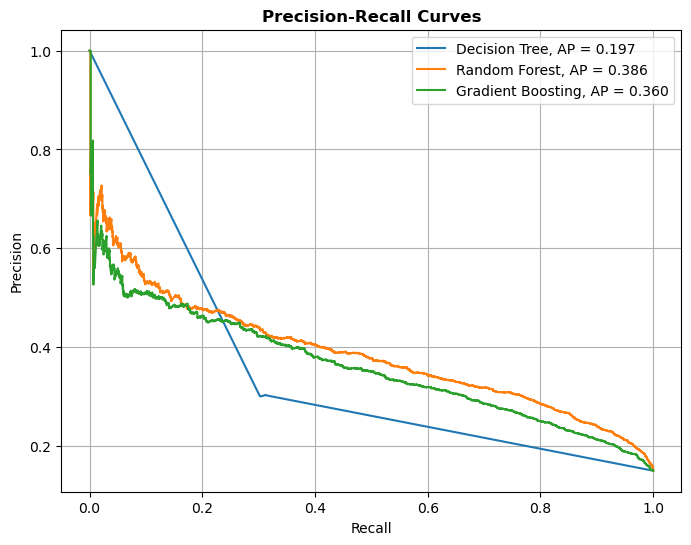

In [23]:
# Compare Precision-Recall curves of the three models

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

models = {
    "Decision Tree": dtc,
    "Random Forest": rfc,
    "Gradient Boosting": gbc
}

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
    avg_precision = average_precision_score(y_test, y_pred_prob)

    plt.plot(
        recall,
        precision,
        label=f"{name}, AP = {avg_precision:.3f}"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves", fontweight="bold")
plt.legend()
plt.grid(True)
plt.show()


AP (Average Precision Score) is a measure of the trade-off between precision and recall. It tells us how close the curve is to the top-right corner of the plot, where the perfect ranking (AP = 1) is achieved.

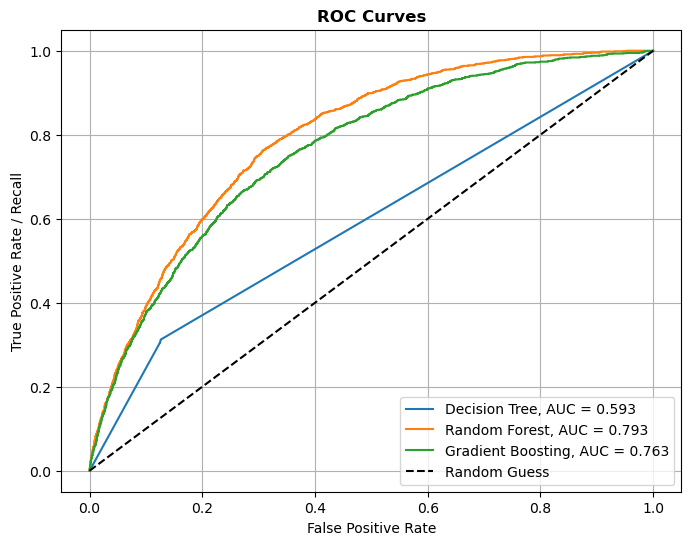

In [25]:
# Compare ROC curves of the three models

from sklearn.metrics import roc_curve, auc

models = {
    "Decision Tree": dtc,
    "Random Forest": rfc,
    "Gradient Boosting": gbc
}

plt.figure(figsize=(8, 6))

for model_name, model in models.items():
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{model_name}, AUC = {roc_auc:.3f}")

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("ROC Curves", fontweight="bold")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
# Random Forest Classifier

# Predict using the model
y_pred_rfc = rfc.predict(X_test)

# Predict probabilities of each booking session in the test set having a completed booking (which is in the 2nd column of the output of .predict_proba)
y_pred_prob_rfc = rfc.predict_proba(X_test)
booking_prob_rfc = y_pred_prob_rfc[:,1]  

ac_rfc = accuracy_score(y_test, y_pred_rfc)
f1_rfc = f1_score(y_test, y_pred_rfc, average='macro')
ll_rfc = log_loss(y_test, y_pred_prob_rfc)
cm_rfc = confusion_matrix(y_test, y_pred_rfc)
cr_rfc = classification_report(y_test, y_pred_rfc)

print('Random Forest: Accuracy=%.3f' % (ac_rfc))
print('Random Forest: f1-score=%.3f' % (f1_rfc))
print('Random Forest: log-loss=%.3f' % (ll_rfc))
print(cr_rfc)

Random Forest: Accuracy=0.802
Random Forest: f1-score=0.655
Random Forest: log-loss=0.413
              precision    recall  f1-score   support

           0       0.91      0.86      0.88      8504
           1       0.38      0.50      0.43      1496

    accuracy                           0.80     10000
   macro avg       0.64      0.68      0.65     10000
weighted avg       0.83      0.80      0.81     10000



In [27]:
# Gradient Boosting Classifier

# Predict using the model
y_pred_gbc = gbc.predict(X_test)

# Predict probabilities of each booking session in the test set having a completed booking (which is in the 2nd column of the output of .predict_proba)
y_pred_prob_gbc = gbc.predict_proba(X_test)
booking_prob_gbc = y_pred_prob_gbc[:,1]  

ac_gbc = accuracy_score(y_test, y_pred_gbc)
f1_gbc = f1_score(y_test, y_pred_gbc, average='macro')
ll_gbc = log_loss(y_test, y_pred_prob_gbc)
cm_gbc = confusion_matrix(y_test, y_pred_gbc)
cr_gbc = classification_report(y_test, y_pred_gbc)

print('Gradient Boosting: Accuracy=%.3f' % (ac_gbc))
print('Gradient Boosting: f1-score=%.3f' % (f1_gbc))
print('Gradient Boosting: log-loss=%.3f' % (ll_gbc))
print(cr_gbc)

Gradient Boosting: Accuracy=0.793
Gradient Boosting: f1-score=0.641
Gradient Boosting: log-loss=0.442
              precision    recall  f1-score   support

           0       0.90      0.85      0.87      8504
           1       0.36      0.47      0.41      1496

    accuracy                           0.79     10000
   macro avg       0.63      0.66      0.64     10000
weighted avg       0.82      0.79      0.80     10000



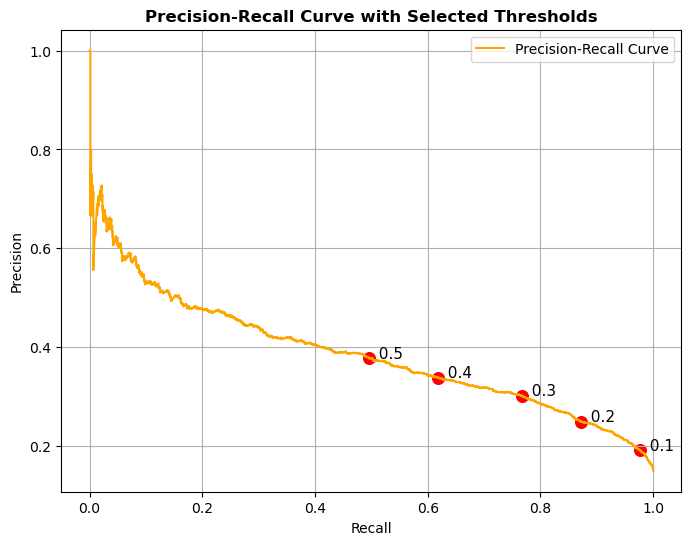

In [28]:
# Compare metrics at different probability thresholds using Precision-Recall Curve
from sklearn.metrics import precision_recall_curve

# Probabilities for class 1
booking_prob_rfc = rfc.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, booking_prob_rfc)

plt.figure(figsize=(8, 6))

# Plot full precision-recall curve
plt.plot(recall, precision, label="Precision-Recall Curve", color="orange")

# Mark selected threshold values
selected_thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

for t in selected_thresholds:
    idx = np.argmin(np.abs(thresholds - t))
    plt.scatter(recall[idx], precision[idx], s=70, marker="o", color="red")
    plt.text(
        recall[idx],
        precision[idx],
        f"  {t}",
        fontsize=11
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve with Selected Thresholds", fontweight="bold")
plt.legend()
plt.grid(True)
plt.show()

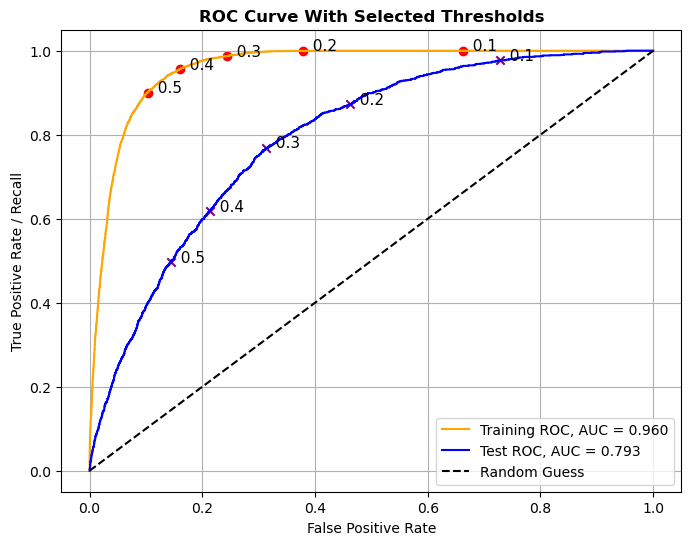

In [29]:
from sklearn.metrics import roc_curve, auc

# Predicted probabilities for class 1
y_train_prob = rfc.predict_proba(X_train)[:, 1]
y_test_prob = rfc.predict_proba(X_test)[:, 1]

# ROC curve values
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_train_prob)
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_prob)

# AUC scores
auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)

# Thresholds you want to mark
selected_thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

plt.figure(figsize=(8, 6))

# Plot ROC curves
plt.plot(fpr_train, tpr_train, label=f"Training ROC, AUC = {auc_train:.3f}", color="orange")
plt.plot(fpr_test, tpr_test, label=f"Test ROC, AUC = {auc_test:.3f}", color="blue")

# Random guessing line
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")

# Mark threshold points
for threshold in selected_thresholds:
    train_idx = np.argmin(np.abs(thresholds_train - threshold))
    test_idx = np.argmin(np.abs(thresholds_test - threshold))

    plt.scatter(fpr_train[train_idx], tpr_train[train_idx], marker="o", color="red")
    plt.text(
        fpr_train[train_idx],
        tpr_train[train_idx],
        f"  {threshold}",
        fontsize=11
    )

    plt.scatter(fpr_test[test_idx], tpr_test[test_idx], marker="x", color="purple")
    plt.text(
        fpr_test[test_idx],
        tpr_test[test_idx],
        f"  {threshold}",
        fontsize=11
    )

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("ROC Curve With Selected Thresholds", fontweight="bold")
plt.legend()
plt.grid(True)
plt.show()

The AUC of the test ROC curve is 0.793, which represents a good seperation between the positive and negative classes. If we randomly pick one customer who completed a booking and one customer who did not, an AUC of 0.793 means there is about a 79% chance the model gives the completed-booking customer a higher predicted probability than the non-booking customer.

AUC does not tell us which threshold to use. It tells you how good the model is overall at separating classes. You still need to choose a threshold based on your goal, such as higher recall or higher precision.


In [30]:
# Compare metrics at different probability thresholds

for threshold in [0.1, 0.2, 0.3, 0.4, 0.5]:
    y_pred = (booking_prob_rfc >= threshold).astype(int)
    
    print("Threshold:", threshold)
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print()

Threshold: 0.1
Precision: 0.19078689808169125
Recall: 0.9772727272727273
F1: 0.31924882629107987
Accuracy: 0.3765

Threshold: 0.2
Precision: 0.24899828277046365
Recall: 0.8723262032085561
F1: 0.38741279501261694
Accuracy: 0.5873

Threshold: 0.3
Precision: 0.30139144132318196
Recall: 0.767379679144385
F1: 0.432799245994345
Accuracy: 0.6991

Threshold: 0.4
Precision: 0.33833211411850767
Recall: 0.6183155080213903
F1: 0.4373522458628841
Accuracy: 0.762

Threshold: 0.5
Precision: 0.37741607324516785
Recall: 0.4959893048128342
F1: 0.4286539572501445
Accuracy: 0.8022



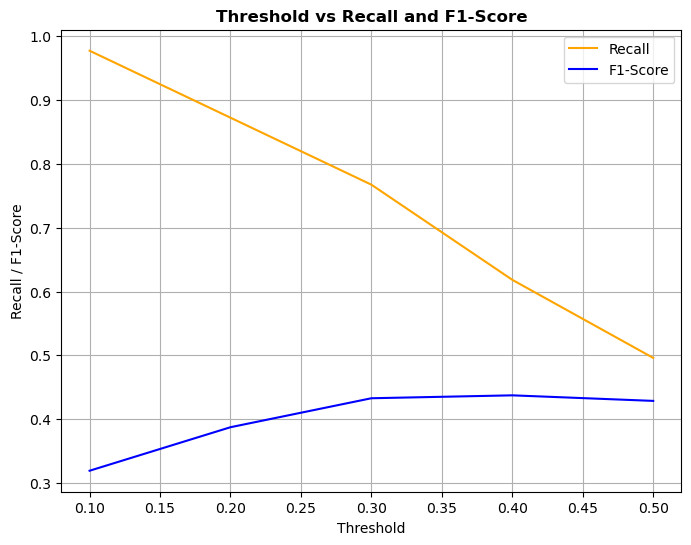

In [31]:
# Plot threshold vs recall and f1-score
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
recalls = []
f1_scores = []

for threshold in thresholds:
    y_pred = (booking_prob_rfc >= threshold).astype(int)
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))

plt.figure(figsize=(8, 6))

plt.plot(thresholds, recalls, label="Recall", color="orange")
plt.plot(thresholds, f1_scores, label="F1-Score", color="blue")

plt.xlabel("Threshold")
plt.ylabel("Recall / F1-Score")
plt.title("Threshold vs Recall and F1-Score", fontweight="bold")
plt.legend()
plt.grid(True)
plt.show()

10


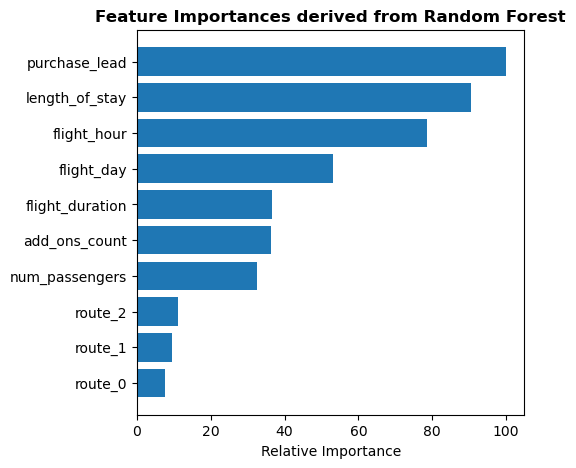

In [32]:
# Plot feature importances
feature_importance = rfc.feature_importances_

# Make importances relative to max importance
relative_importance = 100.0 * (feature_importance / feature_importance.max())[:10]
sorted_idx = np.argsort(relative_importance)[:10]

pos = np.arange(sorted_idx.shape[0]) + .5
print(pos.size)
sorted_idx.size
plt.figure(figsize=(5,5))
plt.barh(pos, relative_importance[sorted_idx], align='center')
plt.yticks(pos, X_train.columns[sorted_idx])
plt.xlabel('Relative Importance')
plt.title('Feature Importances derived from Random Forest',fontsize=12, fontweight="bold")
plt.show()

The top 4 important features are: `purchase_lead`, `length_of_stay`, `flight_hour` and `flight_day`. These features are very important in predicting whether a customer will book a flight or not. The BR airline should focus less on “changing” the customer and more on intervening at the moments where booking completion is most likely to be influenced. Key actions could be as follows:

- **Target customers with high purchase_lead:** If purchase_lead is important, customers booking far in advance behave differently from last-minute customers. Airlines can encourage completion by offering early-bird discounts, limited-time fare holds, reminder emails, and price-lock options.

- **Personalize by length of stay:** length_of_stay can indicate travel purpose.
Short stays may be business or weekend trips; long stays may be leisure. Airlines can tailor messages: flexibility for business travelers, baggage or meal bundles for leisure travelers.

- **Time promotions around flight_hour and flight_day:** If departure time/day are important, some schedules likely convert better than others. Airlines can promote lower-conversion departure times with small fare incentives or highlight convenience benefits for better-performing times.

Random Forest feature importance shows association, not causation. So the best next step is to use these insights to design A/B tests, for example testing fare-hold offers, or time-specific promotions, then measure whether booking completion actually increases.